In [13]:
from synapse_counting import results_plotting
import seaborn as sns
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

In [14]:
# Candidate to make the heatmap of
protein = "VCAM1"

In [15]:
# order to show the metrics and hippocampal layers

metric_order = [
    "presynapse_image_mfi", 
    "pre_staining_area_um2",
    "pre_puncta_density_per_100_um2",
    "pre_mean_puncta_size_um2",
    "postsynapse_image_mfi",
    "post_staining_area_um2",
    "post_puncta_density_per_100_um2",
    "post_mean_puncta_size_um2",
    "local_peak_colocalized_spots",
    "pearson_cor",
    "overlap_coeff",
    "overlap_um2"
    ]

vglut1_hippocampal_layer_order = [
    "CA1 SO",
    "CA1 SR",
    "CA1 SLM",
    "CA3 SO",
    "CA3 SL",
    "CA3 SR",
    "DG ML",
    "DG Hilus"
    ]

vgat_hippocampal_layer_order = [
    "CA1 SO",
    "CA1 SR",
    "CA1 SLM",
    "CA3 SO",
    "CA3 SL",
    "CA3 SR",
    "DG ML",
    "DG Hilus"
    ]

In [16]:
#reading in the VGLUT1-PSD95 data
file_path_vglut1 = f"/Volumes/Intenso/image-analysis/synapse-counting/results_20251203/{protein}_VGLUT1-PSD95_lmem_analysis_results.csv"
df_vglut1 = pd.read_csv(file_path_vglut1)
df_vglut1.head(10)

,hippocampal_layer,contrast,estimate,SE,df,z.ratio,p.value,Mean_LacZ-gRNA,Mean_VCAM1-gRNA,p.value.adj,analyzed_metric,analyzed_protein
0,CA1 SLM,(LacZ-gRNA) - (VCAM1-gRNA),1.274541,0.410100,inf,3.107880,0.001884,9.221493,7.946952,0.002512,local_peak_colocalized_spots,VCAM1
1,CA1 SO,(LacZ-gRNA) - (VCAM1-gRNA),1.367182,0.410100,inf,3.333778,0.000857,8.605758,7.238576,0.001714,local_peak_colocalized_spots,VCAM1
2,CA1 SR,(LacZ-gRNA) - (VCAM1-gRNA),1.275502,0.410100,inf,3.110223,0.001869,9.088621,7.813119,0.002512,local_peak_colocalized_spots,VCAM1
3,CA3 SL,(LacZ-gRNA) - (VCAM1-gRNA),1.875355,0.410100,inf,4.572921,0.000005,7.969555,6.094200,0.000019,local_peak_colocalized_spots,VCAM1
4,CA3 SO,(LacZ-gRNA) - (VCAM1-gRNA),1.485713,0.410100,inf,3.622807,0.000291,8.169021,6.683308,0.000777,local_peak_colocalized_spots,VCAM1
5,CA3 SR,(LacZ-gRNA) - (VCAM1-gRNA),1.970002,0.410100,inf,4.803713,0.000002,7.086731,5.116729,0.000012,local_peak_colocalized_spots,VCAM1
6,DG Hilus,(LacZ-gRNA) - (VCAM1-gRNA),0.449928,0.410100,inf,1.097118,0.272590,7.557617,7.107689,0.272590,local_peak_colocalized_spots,VCAM1
7,DG ML,(LacZ-gRNA) - (VCAM1-gRNA),1.108011,0.410100,inf,2.701808,0.006896,7.275729,6.167718,0.007882,local_peak_colocalized_spots,VCAM1
8,CA1 SLM,(LacZ-gRNA) - (VCAM1-gRNA),0.013331,0.008441,inf,1.579275,0.114273,0.339839,0.326508,0.278950,overlap_coeff,VCAM1
9,CA1 SO,(LacZ-gRNA) - (VCAM1-gRNA),-0.000012,0.008441,inf,-0.001384,0.998895,0.347300,0.347312,0.998895,overlap_coeff,VCAM1


In [17]:
# get the df for adj p values
df_vglut1_adj_p_values = df_vglut1[["hippocampal_layer", "p.value.adj", "analyzed_metric"]]
df_wide_vglut1_p_value = df_vglut1_adj_p_values.pivot(index="analyzed_metric", columns="hippocampal_layer", values="p.value.adj").reindex(metric_order)
df_wide_vglut1_p_value_ordered = df_wide_vglut1_p_value[vglut1_hippocampal_layer_order]
df_wide_vglut1_p_value_ordered.head(12)

hippocampal_layer,CA1 SO,CA1 SR,CA1 SLM,CA3 SO,CA3 SL,CA3 SR,DG ML,DG Hilus
analyzed_metric,,,,,,,,
presynapse_image_mfi,2.382313e-08,2.382313e-08,0.000090,2.144022e-08,3.021999e-11,4.070746e-10,0.015953,0.001478
pre_staining_area_um2,7.724412e-01,2.346402e-02,0.772441,8.512872e-01,8.512872e-01,1.751574e-01,0.023464,0.865872
pre_puncta_density_per_100_um2,9.607168e-01,9.787756e-03,0.764814,9.902015e-01,9.902015e-01,1.613631e-01,0.111217,0.990201
pre_mean_puncta_size_um2,7.350774e-01,7.350774e-01,0.788784,3.858880e-01,3.858880e-01,7.350774e-01,0.061900,0.680660
postsynapse_image_mfi,7.375380e-02,1.796000e-01,0.038607,1.796000e-01,3.368228e-02,2.378091e-02,0.254158,0.304279
post_staining_area_um2,5.594502e-01,5.594502e-01,0.273439,8.503134e-01,8.015397e-01,2.734391e-01,0.908123,0.001427
post_puncta_density_per_100_um2,4.415919e-01,4.415919e-01,0.369504,8.072566e-01,8.072566e-01,2.512655e-01,0.807257,0.001851
post_mean_puncta_size_um2,8.794224e-01,8.794224e-01,0.879422,8.794224e-01,8.794224e-01,8.794224e-01,0.879422,0.879422
local_peak_colocalized_spots,1.713500e-03,2.512464e-03,0.002512,7.771273e-04,1.923883e-05,1.245999e-05,0.007882,0.272590


In [18]:
# get the df for log2 fold change
df_vglut1_log2_fc = df_vglut1[["hippocampal_layer", "estimate", "analyzed_metric"]]
df_wide_vglut1_log2_fc = df_vglut1_log2_fc.pivot(index="analyzed_metric", columns="hippocampal_layer", values="estimate").reindex(metric_order)
df_wide_vglut1_log2_fc_ordered = df_wide_vglut1_log2_fc[vglut1_hippocampal_layer_order]
if protein == "VCAM1":
    df_wide_vglut1_log2_fc_ordered = -df_wide_vglut1_log2_fc_ordered
else: pass
df_wide_vglut1_log2_fc_ordered.head(10)

hippocampal_layer,CA1 SO,CA1 SR,CA1 SLM,CA3 SO,CA3 SL,CA3 SR,DG ML,DG Hilus
analyzed_metric,,,,,,,,
presynapse_image_mfi,-0.541811,-0.543395,-0.381348,-0.551836,-0.664512,-0.618494,-0.230584,-0.307839
pre_staining_area_um2,-0.070414,-0.293715,-0.081127,-0.032647,-0.041028,-0.184659,-0.276418,-0.016946
pre_puncta_density_per_100_um2,-0.042629,-0.263168,-0.071093,0.021362,0.001000,-0.152776,-0.179065,0.010127
pre_mean_puncta_size_um2,-0.003336,-0.002181,-0.001226,-0.006677,-0.007541,-0.002121,-0.012192,-0.004365
postsynapse_image_mfi,-0.158812,-0.113819,-0.186058,-0.114772,-0.200479,-0.226033,-0.092847,-0.078168
post_staining_area_um2,-0.087827,-0.080014,-0.139679,0.027936,-0.044722,0.151837,-0.009873,-0.320637
post_puncta_density_per_100_um2,-0.091136,-0.097306,-0.123914,0.020410,-0.039063,0.155649,-0.021153,-0.308044
post_mean_puncta_size_um2,0.000518,0.001457,-0.002256,0.000873,-0.000635,-0.000720,0.001638,-0.001223
local_peak_colocalized_spots,-1.367182,-1.275502,-1.274541,-1.485713,-1.875355,-1.970002,-1.108011,-0.449928


In [19]:
# reading in the VGAT-GEPH dataset
vgat_results_file = f"/Volumes/Intenso/image-analysis/synapse-counting/results_20251203/{protein}_VGAT-GEPH_lmem_analysis_results.csv"
df_vgat = pd.read_csv(vgat_results_file)
df_vgat.head(10)

,hippocampal_layer,contrast,estimate,SE,df,z.ratio,p.value,Mean_LacZ-gRNA,Mean_VCAM1-gRNA,p.value.adj,analyzed_metric,analyzed_protein
0,CA1 SLM,(LacZ-gRNA) - (VCAM1-gRNA),0.843365,0.378980,inf,2.225357,0.026057,8.071317,7.227952,0.093189,local_peak_colocalized_spots,VCAM1
1,CA1 SO,(LacZ-gRNA) - (VCAM1-gRNA),0.707757,0.378980,inf,1.867533,0.061827,4.803533,4.095776,0.120135,local_peak_colocalized_spots,VCAM1
2,CA1 SR,(LacZ-gRNA) - (VCAM1-gRNA),0.799263,0.378980,inf,2.108986,0.034946,5.683128,4.883865,0.093189,local_peak_colocalized_spots,VCAM1
3,CA3 SL,(LacZ-gRNA) - (VCAM1-gRNA),0.272842,0.378980,inf,0.719939,0.471562,3.943626,3.670784,0.538928,local_peak_colocalized_spots,VCAM1
4,CA3 SO,(LacZ-gRNA) - (VCAM1-gRNA),0.064571,0.378980,inf,0.170381,0.864711,4.876937,4.812366,0.864711,local_peak_colocalized_spots,VCAM1
5,CA3 SR,(LacZ-gRNA) - (VCAM1-gRNA),0.440944,0.378980,inf,1.163502,0.244626,5.663919,5.222975,0.326168,local_peak_colocalized_spots,VCAM1
6,DG Hilus,(LacZ-gRNA) - (VCAM1-gRNA),0.674564,0.378980,inf,1.779947,0.075085,4.645374,3.970810,0.120135,local_peak_colocalized_spots,VCAM1
7,DG ML,(LacZ-gRNA) - (VCAM1-gRNA),1.067846,0.378980,inf,2.817686,0.004837,6.573304,5.505458,0.038697,local_peak_colocalized_spots,VCAM1
8,CA1 SLM,(LacZ-gRNA) - (VCAM1-gRNA),0.037503,0.017839,inf,2.102327,0.035525,0.258200,0.220697,0.284197,overlap_coeff,VCAM1
9,CA1 SO,(LacZ-gRNA) - (VCAM1-gRNA),-0.013236,0.017839,inf,-0.741994,0.458091,0.260029,0.273266,0.956810,overlap_coeff,VCAM1


In [20]:
# get the df with adj pvalues
df_vgat_adj_p_values = df_vgat[["hippocampal_layer", "p.value.adj", "analyzed_metric"]]
df_wide_vgat_p_value = df_vgat_adj_p_values.pivot(index="analyzed_metric", columns="hippocampal_layer", values="p.value.adj").reindex(metric_order)
df_wide_vgat_p_value_ordered = df_wide_vgat_p_value[vglut1_hippocampal_layer_order]
df_wide_vgat_p_value_ordered.head(10)

hippocampal_layer,CA1 SO,CA1 SR,CA1 SLM,CA3 SO,CA3 SL,CA3 SR,DG ML,DG Hilus
analyzed_metric,,,,,,,,
presynapse_image_mfi,0.134772,0.054577,0.077689,0.159522,0.134772,0.077689,0.077689,0.301874
pre_staining_area_um2,0.750622,0.333777,0.005392,0.750622,0.306992,0.306992,0.750622,0.306992
pre_puncta_density_per_100_um2,0.995038,0.530338,0.007068,0.737275,0.313593,0.452686,0.691488,0.452686
pre_mean_puncta_size_um2,0.617889,0.225164,0.040668,0.921594,0.859536,0.148101,0.921594,0.289528
postsynapse_image_mfi,0.648614,0.549522,0.393651,0.648614,0.549522,0.648614,0.755174,0.648614
post_staining_area_um2,0.963074,0.963074,0.963074,0.963074,0.085159,0.963074,0.963074,0.963074
post_puncta_density_per_100_um2,0.939636,0.939636,0.939636,0.939636,0.047265,0.939636,0.939636,0.939636
post_mean_puncta_size_um2,0.190347,0.937435,0.937435,0.937435,0.937435,0.937435,0.937435,0.937435
local_peak_colocalized_spots,0.120135,0.093189,0.093189,0.864711,0.538928,0.326168,0.038697,0.120135


In [21]:
# get the df with log2 fold change
df_vgat_adj_log2_fc = df_vgat[["hippocampal_layer", "estimate", "analyzed_metric"]]
df_wide_vgat_log2_fc = df_vgat_adj_log2_fc.pivot(index="analyzed_metric", columns="hippocampal_layer", values="estimate").reindex(metric_order)
df_wide_vgat_log2_fc_ordered = df_wide_vgat_log2_fc[vglut1_hippocampal_layer_order]
if protein == "VCAM1":
    df_wide_vglut1_log2_fc_ordered = -df_wide_vglut1_log2_fc_ordered
else: pass
df_wide_vgat_log2_fc_ordered.head(10)

hippocampal_layer,CA1 SO,CA1 SR,CA1 SLM,CA3 SO,CA3 SL,CA3 SR,DG ML,DG Hilus
analyzed_metric,,,,,,,,
presynapse_image_mfi,0.171531,0.274298,0.214523,0.149787,0.166242,0.221232,0.209452,0.104676
pre_staining_area_um2,0.065248,-0.258141,0.698005,-0.077757,0.293020,-0.308224,-0.100362,-0.300002
pre_puncta_density_per_100_um2,0.000892,-0.139317,0.477009,-0.066068,0.252483,-0.196153,-0.092595,-0.173552
pre_mean_puncta_size_um2,0.005662,-0.011274,0.018305,-0.001112,0.003013,-0.013626,-0.000643,-0.009528
postsynapse_image_mfi,0.048897,0.105694,0.164403,0.056244,0.118034,-0.047786,0.026065,0.075474
post_staining_area_um2,-0.280978,0.074141,0.056007,0.133567,-1.139381,0.020652,0.020883,-0.314482
post_puncta_density_per_100_um2,-0.053145,0.046709,0.047935,0.105241,-1.123811,0.030915,0.039656,-0.190307
post_mean_puncta_size_um2,-0.027674,0.003511,0.000961,0.002371,0.003621,-0.001166,-0.001250,-0.011278
local_peak_colocalized_spots,0.707757,0.799263,0.843365,0.064571,0.272842,0.440944,1.067846,0.674564


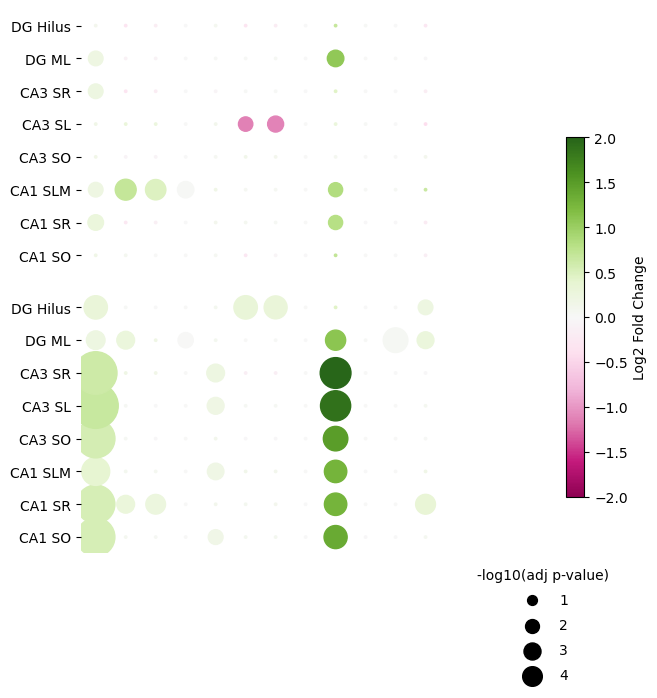

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.colors import Normalize

# Set up the figure
fig = plt.figure(figsize=(6.5, 8))

# Create a grid for the main plots and the legend
gs = fig.add_gridspec(3, 2, width_ratios=[3, 1], height_ratios=[1, 1, 0.2], hspace=0.1, wspace=0.1)

# Data and parameters for each plot
data_sets = [
    (df_wide_vgat_p_value_ordered, df_wide_vgat_log2_fc_ordered, vgat_hippocampal_layer_order),
    (df_wide_vglut1_p_value_ordered, df_wide_vglut1_log2_fc_ordered, vglut1_hippocampal_layer_order)
]
titles = ['VGAT', 'VGLUT1']

# Create subplots for the main plots
axes = [fig.add_subplot(gs[i, 0]) for i in range(2)]

for i, (ax, (df_p_value, df_log2_fc, hippocampal_layer_order)) in enumerate(zip(axes, data_sets)):
    # Remove spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)

    # Flatten the data
    x_vals = np.repeat(range(len(metric_order)), len(hippocampal_layer_order))
    y_vals = np.tile(range(len(hippocampal_layer_order)), len(metric_order))
    sizes = df_p_value.values.flatten()
    sizes_log = -np.log10(sizes) * 100
    colors = df_log2_fc.values.flatten()

    # Apply cutoff
    cutoff = 1
    sizes_log[sizes_log < (cutoff * 100)] = 3

    # Create scatter plot
    norm = Normalize(vmin=-2, vmax=2)
    scatter = ax.scatter(x_vals, y_vals, s=sizes_log, c=colors, cmap='PiYG', norm=norm)
    
    # Adjust x and y limits to avoid cutting off points
    ax.set_xlim(-0.5, len(metric_order) - 0.5)
    ax.set_ylim(-0.5, len(hippocampal_layer_order) - 0.5)
    
    # Set y ticks for each plot
    ax.set_yticks(range(len(hippocampal_layer_order)))
    ax.set_yticklabels(hippocampal_layer_order)

    # Only set x ticks for the bottom plot
    if i == 2:  # Bottom plot
        ax.set_xticks(range(len(metric_order)))
        ax.set_xticklabels(metric_order, rotation=90)
    else:
        ax.set_xticks([])

    # Set title for each subplot
    #ax.set_title(titles[i], y=1.0, pad=-14)

# Create a subplot for the legends
legend_ax = fig.add_subplot(gs[:, 1])
legend_ax.axis('off')

# Add a colorbar
cbar = fig.colorbar(scatter, ax=legend_ax, shrink=0.8, aspect=20, pad=0.05)
cbar.set_label("Log2 Fold Change")

# Create a legend for dot sizes
size_legend_labels = [1, 2, 3, 4]
size_legend = [plt.scatter([], [], s=size*50, edgecolor='black', facecolor='black') for size in size_legend_labels]
legend_ax.legend(size_legend, [f'{label}' for label in size_legend_labels],
                 title='-log10(adj p-value)', loc='center left', bbox_to_anchor=(0, 0),
                 handletextpad=1, labelspacing=0.8, frameon=False)



#plt.savefig(f"/Volumes/KINGSTON/data/phd/image-analysis/synapse-counting/{protein}_dotplot", dpi=600, bbox_inches = "tight")
#plt.tight_layout()
plt.show()

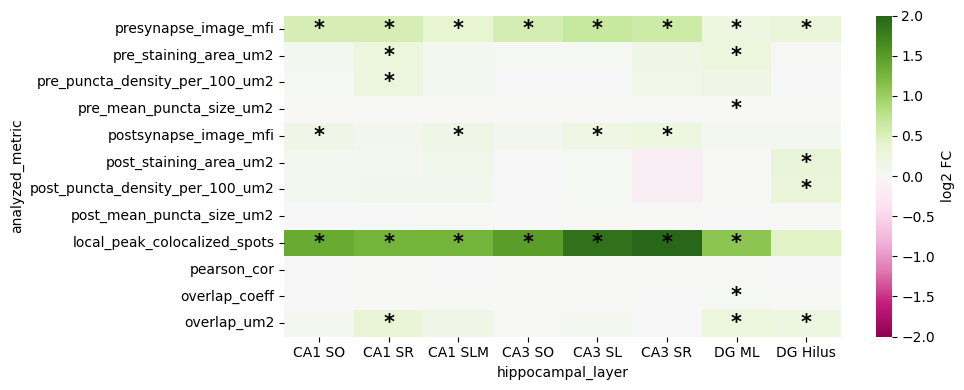

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(df_wide_vglut1_log2_fc_ordered, 
            cmap='PiYG',  
            center=0,  
            annot=False,  
            cbar_kws={'label': 'log2 FC'},
            ax=ax,
            vmin=-2,
            vmax=2)

significance_threshold = 0.1


for i in range(df_wide_vglut1_p_value_ordered.shape[0]):
    for j in range(df_wide_vglut1_p_value_ordered.shape[1]):
        if df_wide_vglut1_p_value_ordered.iloc[i, j] < significance_threshold:  # Use .iloc for DataFrame
            ax.text(j + 0.5, i + 0.5, '*',
                   ha='center', va='center',
                   color='black', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

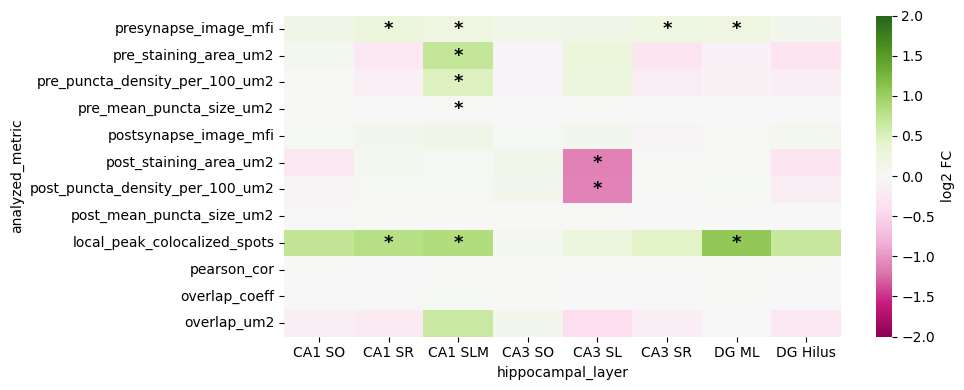

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(df_wide_vgat_log2_fc_ordered, 
            cmap='PiYG',  
            center=0,  
            annot=False,  
            cbar_kws={'label': 'log2 FC'},
            ax=ax,
            vmin=-2,
            vmax=2)

significance_threshold = 0.1

for i in range(df_wide_vgat_p_value_ordered.shape[0]):
    for j in range(df_wide_vgat_p_value_ordered.shape[1]):
        if df_wide_vgat_p_value_ordered.iloc[i, j] < significance_threshold:  # Use .iloc for DataFrame
            ax.text(j + 0.5, i + 0.5, '*',
                   ha='center', va='center',
                   color='black', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()